In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_pickle('../data/df_ndvi_rendvi.pkl')

In [4]:
df.shape

(585, 231)

In [5]:
# --- Identify leakage columns ---
leakage_cols = [col for col in df.columns if any(
    col.endswith(f"_{m}") for m in range(36,45)
)]
leakage_cols.extend([col for col in df.columns if col.endswith('length')])
leakage_cols.extend([col for col in df.columns if 'mcari2' in col])

In [6]:
df = df.copy()

In [7]:
dynamic_features = ['ndvi','rendvi', 'tmean', 'tmin', 'tmax', 'gdd', 'vpdmax']


In [8]:
# sq_dfs = []
# cu_dfs = []
# for feature in dynamic_features:
#     # find all columns related to that feature, excluding any "leakage" columns
#     feature_cols = [col for col in df.columns if feature in col and col not in leakage_cols]
    
#     # create squared versions with clear new names
#     sq_df = df[feature_cols] ** 2
#     sq_df.columns = [f"{col}_sq" for col in feature_cols]
    
#     sq_dfs.append(sq_df)
    
# #     cu_df = df[feature_cols] ** 3
# #     cu_df.columns = [f"{col}_cu" for col in feature_cols]
    
# #     cu_dfs.append(cu_df)

# # concatenate all squared DataFrames horizontally
# sq_df_all = pd.concat(sq_dfs, axis=1)
# # cu_df_all = pd.concat(cu_dfs, axis=1)

# # merge back into original dataframe (optional)
# df_poly = pd.concat([df, sq_df_all], axis=1)


In [9]:
# ppt_cols = [col for col in df_poly.columns if 'ppt' in col]

In [10]:
# slope_cols = [col for col in df_poly.columns if 'slope_mean' in col]

In [13]:


# --- Define target and features ---
target_cols = [
    'ndvi_smooth_mean_36',
    'ndvi_smooth_mean_37',
    'ndvi_smooth_mean_38',
    'ndvi_smooth_mean_39',
    'ndvi_smooth_mean_40',
    'ndvi_smooth_mean_41',
    'ndvi_smooth_mean_42',
    'ndvi_smooth_mean_43',
    'ndvi_smooth_mean_44',
    
    'rendvi_smooth_mean_36',
    'rendvi_smooth_mean_37',
    'rendvi_smooth_mean_38',
    'rendvi_smooth_mean_39',
    'rendvi_smooth_mean_40',
    'rendvi_smooth_mean_41',
    'rendvi_smooth_mean_42',
    'rendvi_smooth_mean_43',
    'rendvi_smooth_mean_44',
    
    
#     'evi_smooth_mean_36',
#     'evi_smooth_mean_37',
#     'evi_smooth_mean_38',
#     'evi_smooth_mean_39',
#     'evi_smooth_mean_40',
#     'evi_smooth_mean_41',
#     'evi_smooth_mean_42',
#     'evi_smooth_mean_43',
#     'evi_smooth_mean_44',
    
    
#     'mcari2_smooth_mean_36',
#     'mcari2_smooth_mean_37',
#     'mcari2_smooth_mean_38',
#     'mcari2_smooth_mean_39',
#     'mcari2_smooth_mean_40',
#     'mcari2_smooth_mean_41',
#     'mcari2_smooth_mean_42',
#     'mcari2_smooth_mean_43',
#     'mcari2_smooth_mean_44',
    
    
    # 'savi_smooth_mean_36',
    # 'savi_smooth_mean_37',
    # 'savi_smooth_mean_38',
    # 'savi_smooth_mean_39',
    # 'savi_smooth_mean_40',
    # 'savi_smooth_mean_41',
    # 'savi_smooth_mean_42',
    # 'savi_smooth_mean_43',
    # 'savi_smooth_mean_44',
    
    
    # 'ndwi_smooth_mean_36',
    # 'ndwi_smooth_mean_37',
    # 'ndwi_smooth_mean_38',
    # 'ndwi_smooth_mean_39',
    # 'ndwi_smooth_mean_40',
    # 'ndwi_smooth_mean_41',
    # 'ndwi_smooth_mean_42',
    # 'ndwi_smooth_mean_43',
    # 'ndwi_smooth_mean_44',


]
X = df.drop(columns=leakage_cols + ['plot_id', 'year'] + target_cols)
y = df[target_cols]

In [14]:
from sklearn.model_selection import train_test_split

X_test, X_hold, y_test, y_hold = train_test_split(
    X, y, test_size = 0.8, random_state = 42
)

X_train, X_tune, y_train, y_tune = train_test_split(
    X_hold, y_hold, test_size = 0.25, random_state = 42
)

In [15]:
print(X_train.shape)
print(X_tune.shape)
print(X_test.shape)

print(y_train.shape)
print(y_tune.shape)
print(y_test.shape)

(351, 175)
(117, 175)
(117, 175)
(351, 18)
(117, 18)
(117, 18)


In [16]:
X_train.select_dtypes(include=['float64', 'int64']).columns


Index(['ndvi_smooth_mean_28', 'ndvi_smooth_mean_29', 'ndvi_smooth_mean_30',
       'ndvi_smooth_mean_31', 'ndvi_smooth_mean_32', 'ndvi_smooth_mean_33',
       'ndvi_smooth_mean_34', 'ndvi_smooth_mean_35', 'ndvi_smooth_slope_28',
       'ndvi_smooth_slope_29',
       ...
       'ppt_week_sum_33_pro_curve_mean', 'ppt_week_sum_33_plan_curve_mean',
       'ppt_week_sum_34_slope_rad_mean_x', 'ppt_week_sum_34_slope_rad_mean_y',
       'ppt_week_sum_34_pro_curve_mean', 'ppt_week_sum_34_plan_curve_mean',
       'ppt_week_sum_35_slope_rad_mean_x', 'ppt_week_sum_35_slope_rad_mean_y',
       'ppt_week_sum_35_pro_curve_mean', 'ppt_week_sum_35_plan_curve_mean'],
      dtype='object', length=175)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1️⃣ Define preprocessing
# -----------------------------
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns

numeric_transformer = Pipeline(steps = [
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features)
    ],
    remainder = 'drop'
)

In [16]:
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
# from sklearn.linear_model import Ridge, Lasso
# from sklearn.compose import TransformedTargetRegressor

# # --------------------------
# # Base models
# # --------------------------
# from sklearn.svm import SVR
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.ensemble import ExtraTreesRegressor
# from xgboost import XGBRegressor  # optional if you have it

# base_models = [
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)),
#     ('et', ExtraTreesRegressor(n_estimators=300, max_depth=12, random_state=42)),  # decorrelated RF
#     ('gb', GradientBoostingRegressor(n_estimators=150, max_depth=8, random_state=42)),
#     ('xgb', XGBRegressor(
#         n_estimators=200, learning_rate=0.05, max_depth=6,
#         subsample=0.8, colsample_bytree=0.8, random_state=42
#     )),
#     ('ridge', Ridge(alpha=1.0)),
#     ('lasso', Lasso(alpha=0.05, max_iter=10000)),
#     ('knn', KNeighborsRegressor(n_neighbors=8, weights='distance'))
# ]

# # --------------------------
# # Stacked model
# # --------------------------
# stacked_model = StackingRegressor(
#     estimators=base_models,
#     final_estimator=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
#     cv=5,
#     passthrough=True,
#     n_jobs=-1
# )

# multi_output_model = MultiOutputRegressor(stacked_model, n_jobs=-1)

# # --------------------------
# # Pipeline
# # --------------------------
# model_pipeline = Pipeline([
#     ('preprocessor', preprocessor),  # your feature transformer
#     ('regressor', TransformedTargetRegressor(
#         regressor=multi_output_model,
#         transformer=StandardScaler()  # scales y
#     ))
# ])


In [17]:
import sys
!{sys.executable} -m pip install xgboost

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor
)
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

# Optional: uncomment if you have xgboost installed
from xgboost import XGBRegressor

# --------------------------
# Base models
# --------------------------
base_models = [
    ('rf', RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    )),
    ('et', ExtraTreesRegressor(
        n_estimators=300, max_depth=12, random_state=42, n_jobs=-1
    )),
    ('gb', GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=8, random_state=42
    )),
    ('xgb', XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.5, colsample_bytree=0.5, random_state=42, n_jobs=-1
    )),
    # ('ridge', Ridge(alpha=1.0)),
    # ('lasso', Lasso(alpha=1, max_iter=50000)),
    ('knn', KNeighborsRegressor(n_neighbors=8, weights='distance', n_jobs=-1))
]

# --------------------------
# Meta-learner (final estimator)
# --------------------------
meta_model = ElasticNetCV(
    l1_ratio=[0.5, 0.7, 0.9],
    alphas=np.logspace(-2, 1, 10),  # from 0.1 to 10
    cv=5,
    max_iter=20000,
    n_jobs=-1
)

# --------------------------
# Stacked model
# --------------------------
stacked_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    cv=5,
    n_jobs=-1
)

# --------------------------
# Multi-output wrapper
# --------------------------
multi_output_model = MultiOutputRegressor(stacked_model, n_jobs=-1)

# --------------------------
# Full pipeline
# --------------------------
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),  # your feature transformer
    ('regressor', TransformedTargetRegressor(
        regressor=multi_output_model,
        transformer=StandardScaler()  # scales NDWI targets
    ))
])

# --------------------------
# Fit example
# --------------------------
# model_pipeline.fit(X_train, y_train)
# y_pred = model_pipeline.predict(X_test)


In [19]:
dupes = X_train.columns[X_train.columns.duplicated()]
print(dupes)


Index([], dtype='object')


In [22]:
# Basic shape
print(y.shape)

# Column names (if multi-output)
print(y.columns)

# Summary stats for each target
print(y.describe())

# Quick value range check
for col in y.columns:
    print(f"{col}: min={y[col].min():.3f}, max={y[col].max():.3f}, mean={y[col].mean():.3f}")


(585, 18)
Index(['ndvi_smooth_mean_36', 'ndvi_smooth_mean_37', 'ndvi_smooth_mean_38',
       'ndvi_smooth_mean_39', 'ndvi_smooth_mean_40', 'ndvi_smooth_mean_41',
       'ndvi_smooth_mean_42', 'ndvi_smooth_mean_43', 'ndvi_smooth_mean_44',
       'rendvi_smooth_mean_36', 'rendvi_smooth_mean_37',
       'rendvi_smooth_mean_38', 'rendvi_smooth_mean_39',
       'rendvi_smooth_mean_40', 'rendvi_smooth_mean_41',
       'rendvi_smooth_mean_42', 'rendvi_smooth_mean_43',
       'rendvi_smooth_mean_44'],
      dtype='object')
       ndvi_smooth_mean_36  ndvi_smooth_mean_37  ndvi_smooth_mean_38  \
count           585.000000           585.000000           585.000000   
mean              0.455543             0.451412             0.445116   
std               0.107594             0.106924             0.104033   
min               0.143625             0.140757             0.137742   
25%               0.375746             0.367887             0.367205   
50%               0.455539             0.450275

In [18]:
# Keras multi-output CV pipeline
import numpy as np
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import random
import os

# reproducibility helpers
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# X, y: your data. If pandas DataFrame/Series:
# X = X.values
# y = y.values

# config
n_splits = 5
epochs = 400
batch_size = 32
input_dim = X.shape[1]
n_outputs = y.shape[1]

def build_model(input_dim, n_outputs, lr=1e-3, dropout=0.2):
    inp = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inp)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    out = Dense(n_outputs, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse')  # we'll evaluate R2 post-hoc
    return model

# scale X and y inside each fold to avoid leakage
kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

r2_means = []
r2_per_target = []  # will store arrays

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]


    # scale features
    x_scaler = StandardScaler().fit(X_tr)
    X_tr_s = x_scaler.transform(X_tr)
    X_val_s = x_scaler.transform(X_val)

    # scale targets
    y_scaler = StandardScaler().fit(y_tr)
    y_tr_s = y_scaler.transform(y_tr)
    y_val_s = y_scaler.transform(y_val)

    model = build_model(input_dim, n_outputs, lr=1e-3, dropout=0.2)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=0)
    ]

    history = model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_val_s, y_val_s),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    y_val = np.asarray(y_val)
    y_pred = np.asarray(y_pred)
    # predictions (scale back)
    y_pred_s = model.predict(X_val_s)
    y_pred = y_scaler.inverse_transform(y_pred_s)

    # compute per-target R2 and mean R2
    r2s = []
    for j in range(n_outputs):
        r2 = r2_score(y_val[:, j], y_pred[:, j])
        r2s.append(r2)
    r2s = np.array(r2s)
    print(f"Fold {fold+1} mean R2 = {r2s.mean():.4f}  |  per-target (first 6) = {r2s[:6]}")
    r2_means.append(r2s.mean())
    r2_per_target.append(r2s)

# summary
r2_means = np.array(r2_means)
r2_per_target = np.stack(r2_per_target)  # shape (n_folds, n_outputs)
print("\n=== CV summary ===")
print(f"CV mean R2 = {r2_means.mean():.4f} ± {r2_means.std():.4f}")
per_target_mean = r2_per_target.mean(axis=0)
for i, val in enumerate(per_target_mean):
    print(f"target {i:02d}: mean R2 = {val:.4f}")


2025-10-23 08:39:27.680246: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-23 08:39:27.749799: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-23 08:39:29.376433: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.



--- Fold 1/5 ---


2025-10-23 08:39:29.608120: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


NameError: name 'y_pred' is not defined

In [19]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# -----------------------------
# Parameters
# -----------------------------
n_splits = 5
input_dim = X.shape[1]
output_dim = y.shape[1]
epochs = 500
batch_size = 32

# -----------------------------
# Scale features and targets
# -----------------------------
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

# -----------------------------
# Cross-validation setup
# -----------------------------
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_r2s = []
val_r2s = []
per_target_val = []

# -----------------------------
# CV Loop
# -----------------------------
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_scaled)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    
    X_tr, X_val_fold = X_scaled[tr_idx], X_scaled[val_idx]
    y_tr, y_val_fold = y_scaled[tr_idx], y_scaled[val_idx]
    
    # -----------------------------
    # Build small NN
    # -----------------------------
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(output_dim, activation='linear')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='mse')
    
    # Early stopping to prevent overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True
    )
    
    # Fit model
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_fold, y_val_fold),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop]
    )
    
    # -----------------------------
    # Predict and inverse-transform
    # -----------------------------
    y_tr_pred = scaler_y.inverse_transform(model.predict(X_tr))
    y_val_pred = scaler_y.inverse_transform(model.predict(X_val_fold))
    
    y_tr_orig = scaler_y.inverse_transform(y_tr)
    y_val_orig = scaler_y.inverse_transform(y_val_fold)
    
    # -----------------------------
    # Compute R²
    # -----------------------------
    train_r2 = np.mean([r2_score(y_tr_orig[:, j], y_tr_pred[:, j])
                        for j in range(output_dim)])
    val_r2 = np.mean([r2_score(y_val_orig[:, j], y_val_pred[:, j])
                      for j in range(output_dim)])
    
    train_r2s.append(train_r2)
    val_r2s.append(val_r2)
    
    per_target_val.append([r2_score(y_val_orig[:, j], y_val_pred[:, j])
                           for j in range(output_dim)])
    
    print(f"Fold {fold+1} train R² = {train_r2:.3f} | val R² = {val_r2:.3f}")

# -----------------------------
# CV Summary
# -----------------------------
per_target_val = np.array(per_target_val)
print("\n=== CV Summary ===")
print("Train R² mean ± std:", np.mean(train_r2s), "±", np.std(train_r2s))
print("Val R² mean ± std:", np.mean(val_r2s), "±", np.std(val_r2s))

for j in range(output_dim):
    print(f"Target {j:02d} mean R² = {per_target_val[:, j].mean():.3f}")



--- Fold 1/5 ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Fold 1 train R² = 0.957 | val R² = 0.900

--- Fold 2/5 ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Fold 2 train R² = 0.916 | val R² = 0.907

--- Fold 3/5 ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Fold 3 train R² = 0.900 | val R² = 0.891

--- Fold 4/5 ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Fold 4 train R² = 0.930 | val R² = 0.889

--- Fold 5/5 ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Fold 5 train R² = 0.911 | val R² = 0.888

=== CV Summary ===
Train R² mean ± std: 0.9226680467768382 ± 0.019758043805664562
Val R² mean ± std: 0.8948870165151934 ± 0.007087367659654435
Target 00 mean R² = 0.981
Target 01 mean R² = 0.975
Target 02 mean R² = 0.961
Target 03 mean R² = 0.945
Target 04 mean R² = 0.923
Target 05 mean R² = 0.899
Target 06 mean 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


/tmp/ipykernel_146020/57556366.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', n_weeks)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


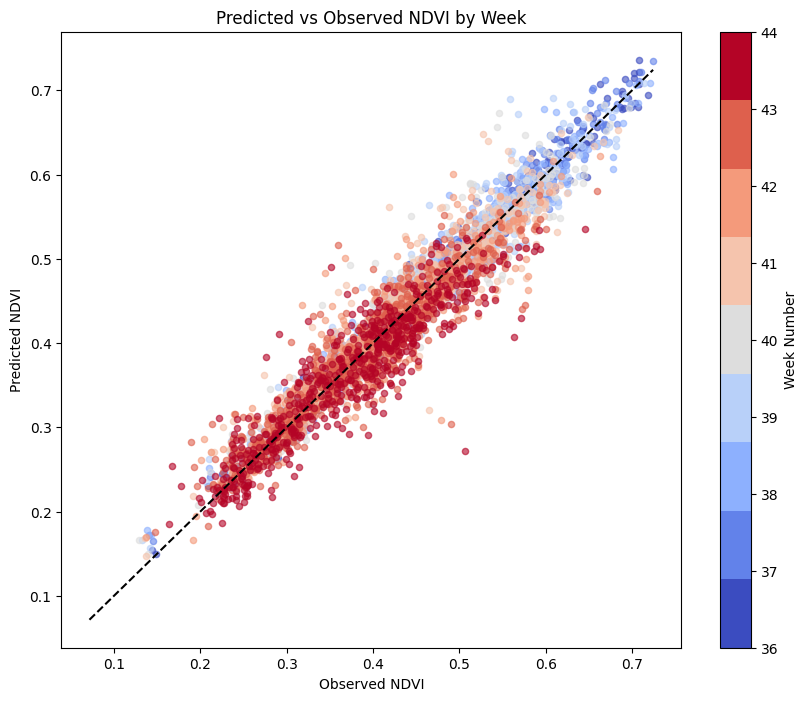

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Define weeks
weeks = range(36, 45)  # your 36–44 weeks
n_weeks = len(weeks)

# Colormap
cmap = cm.get_cmap('coolwarm', n_weeks)
norm = plt.Normalize(vmin=0, vmax=n_weeks - 1)

# Concatenate all CV predictions and observations for plotting
y_obs_all = np.vstack([scaler_y.inverse_transform(y_scaled[val_idx]) for _, val_idx in kf.split(X_scaled)])
y_pred_all = np.vstack([scaler_y.inverse_transform(model.predict(X_scaled[val_idx])) for _, val_idx in kf.split(X_scaled)])

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

for i, week in enumerate(weeks):
    color = cmap(norm(i))
    ax.scatter(y_obs_all[:, i], y_pred_all[:, i], color=color, s=20, alpha=0.6, label=f"Week {week}")

# 1:1 line
ax.plot([y_obs_all.min(), y_obs_all.max()],
        [y_obs_all.min(), y_obs_all.max()], 'k--')

# Labels and title
ax.set_xlabel("Observed NDVI")
ax.set_ylabel("Predicted NDVI")
ax.set_title("Predicted vs Observed NDVI by Week")

# Colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks(np.linspace(0, n_weeks - 1, n_weeks))
cbar.ax.set_yticklabels([str(w) for w in weeks])
cbar.set_label("Week Number")

plt.show()


In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import imageio
import os

# -----------------------------
# Parameters
# -----------------------------
weeks = range(36, 45)
n_weeks = len(weeks)
cmap = cm.get_cmap('coolwarm', n_weeks)
norm = plt.Normalize(vmin=0, vmax=n_weeks - 1)

output_dir = "ndvi_gif_frames"
os.makedirs(output_dir, exist_ok=True)

# Use all CV predictions and observations
y_obs_all = np.vstack([scaler_y.inverse_transform(y_scaled[val_idx]) for _, val_idx in kf.split(X_scaled)])
y_pred_all = np.vstack([scaler_y.inverse_transform(model.predict(X_scaled[val_idx])) for _, val_idx in kf.split(X_scaled)])

frame_files = []

# -----------------------------
# Generate frames
# -----------------------------
for i, week in enumerate(weeks):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for j in range(i+1):  # show all weeks up to current
        color = cmap(norm(j))
        ax.scatter(y_obs_all[:, j], y_pred_all[:, j], color=color, s=20, alpha=0.6, label=f"Week {weeks[j]}")
    
    # 1:1 reference line
    ax.plot([y_obs_all.min(), y_obs_all.max()],
            [y_obs_all.min(), y_obs_all.max()], 'k--')
    
    ax.set_xlabel("Observed NDVI")
    ax.set_ylabel("Predicted NDVI")
    ax.set_title(f"NDVI Predictions Up to Week {weeks[i]}")
    
    # optional: legend for clarity
    ax.legend(loc='upper left', fontsize=8)
    
    # Save frame
    filename = os.path.join(output_dir, f"frame_{i:02d}.png")
    plt.savefig(filename)
    plt.close(fig)
    frame_files.append(filename)

# -----------------------------
# -----------------------------
# Build looping GIF
# -----------------------------
gif_path = "ndvi_predictions.gif"
with imageio.get_writer(gif_path, mode='I', duration=500, loop=0) as writer:  # loop=0 means infinite loop
    for filename in frame_files:
        image = imageio.imread(filename)
        writer.append_data(image)
        # last frame with longer pause (1 second instead of 0.8)
    last_image = imageio.imread(frame_files[-1])
    writer.append_data(last_image)
    writer.append_data(last_image)  # duplicate to increase pause
    writer.append_data(last_image)  # duplicate to increase pause
    writer.append_data(last_image)  # duplicate to increase pause
    writer.append_data(last_image)  # duplicate to increase pause
    writer.append_data(last_image)  # duplicate to increase pause
    writer.append_data(last_image)  # duplicate to increase pause

print(f"GIF saved to {gif_path} (loops indefinitely)")



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/tmp/ipykernel_146020/2306976367.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', n_weeks)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/tmp/ipykernel_146020/2306976367.py:58: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
/tmp/ipykernel_146020/2306976367.py:61: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  last_image = imageio.imread(frame_files[-1])


GIF saved to ndvi_predictions.gif (loops indefinitely)


In [ ]:
crash()

/tmp/ipykernel_85213/2967258583.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', n_weeks)


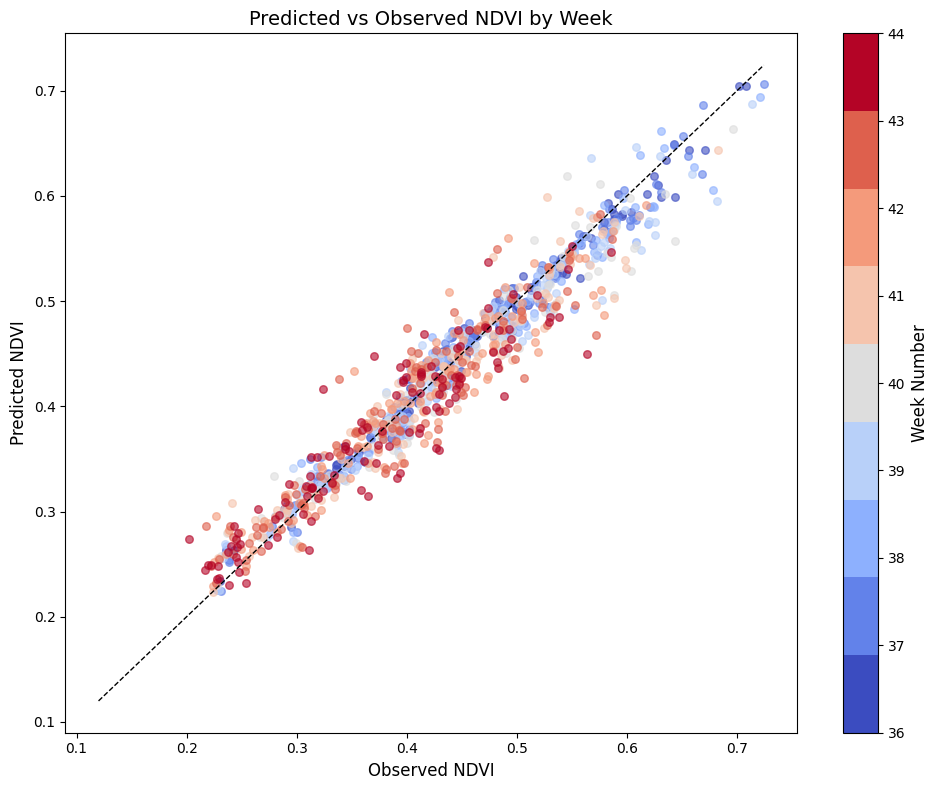

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Define weeks
weeks = range(36, 45)  # NDVI weeks
n_weeks = len(weeks)

# Colormap
cmap = cm.get_cmap('coolwarm', n_weeks)
norm = plt.Normalize(vmin=0, vmax=n_weeks - 1)

# Prepare figure
fig, ax = plt.subplots(figsize=(10, 8))

# Ensure y_val and y_pred are numpy arrays
y_val = np.array(y_val)      # true NDVI, shape: (n_samples, n_weeks)
y_pred = np.array(y_pred)    # predicted NDVI, shape: (n_samples, n_weeks)

# Scatter plot for each week
for i, week in enumerate(weeks):
    color = cmap(norm(i))
    ax.scatter(y_val[:, i], y_pred[:, i],
               color=color, s=30, alpha=0.6, label=f"Week {week}")

# 1:1 reference line
ax.plot([y_val.min(), y_val.max()],
        [y_val.min(), y_val.max()],
        'k--', lw=1, label='1:1 line')

# Axis labels and title
ax.set_xlabel("Observed NDVI", fontsize=12)
ax.set_ylabel("Predicted NDVI", fontsize=12)
ax.set_title("Predicted vs Observed NDVI by Week", fontsize=14)

# Colorbar for weeks
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, ticks=range(n_weeks))
cbar.ax.set_yticklabels([str(w) for w in weeks])
cbar.set_label("Week Number", fontsize=12)

# Optional: place legend outside
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


/tmp/ipykernel_85213/3146379470.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', n_weeks)


NameError: name 'ndvi_obs' is not defined

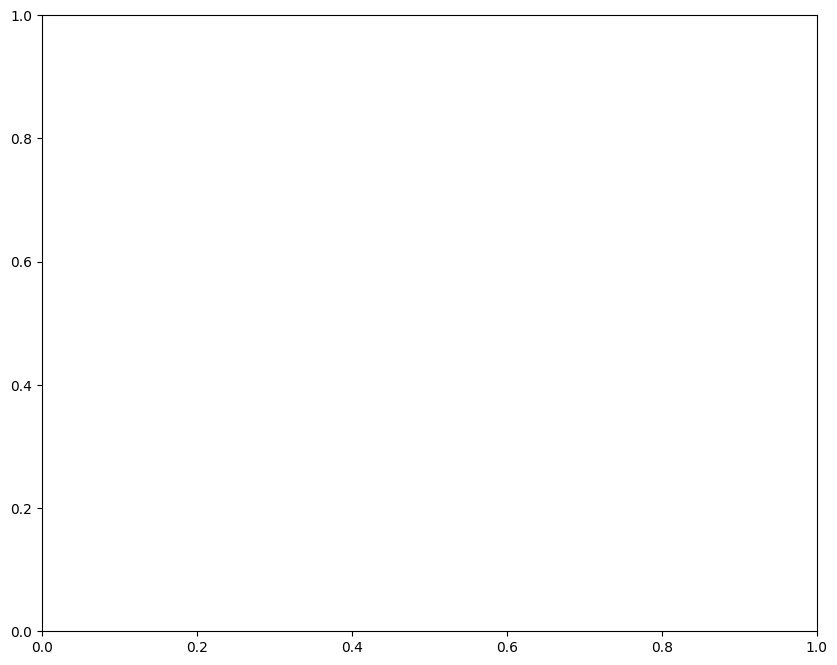

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose y_val and y_pred are numpy arrays of shape (n_samples, n_weeks)
# And week labels are the column names for NDVI
ndvi_weeks = [f'ndvi_smooth_mean_{i}' for i in range(36, 45)]  # weeks 36-44
n_weeks = len(ndvi_weeks)

# Generate a colormap from blue (early) to red (late)
colors = plt.cm.coolwarm(np.linspace(0, 1, n_weeks))

plt.figure(figsize=(12, 6))
for i, week in enumerate(ndvi_weeks):
    plt.scatter(
        y_val[:, i],        # true values
        y_pred[:, i],       # predicted values
        color=colors[i],
        alpha=0.6,
        label=week
    )

# 1:1 line for reference
min_val = np.min(y_val)
max_val = np.max(y_val)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='1:1 line')

plt.xlabel("Observed NDVI")
plt.ylabel("Predicted NDVI")
plt.title("Predicted vs Observed NDVI (weeks 36–44)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [21]:
crash()

NameError: name 'crash' is not defined

In [ ]:
import os
import joblib

model_path = "model_pipeline.pkl"

if os.path.exists(model_path):
    # Load the model
    model_pipeline = joblib.load(model_path)
    print("Model loaded from file.")
else:
    # Fit your model
    model_pipeline.fit(X_train, y_train)
    
    # Save it
    joblib.dump(model_pipeline, model_path)
    print("Model trained and saved.")
# model_pipeline.fit(X_train, y_train)

In [ ]:
df

In [ ]:
y

In [ ]:
# expected_cols = X_train.columns
# dynamic_features = ['ndwi']


In [ ]:
# expected_cols = X_train.columns

# # Prepare a list to collect weekly DataFrames
# weekly_dfs = []

# for week in future_weeks:
#     # 1️⃣ Predict
#     X_pred = df[expected_cols]
#     y_pred = model_pipeline.predict(X_pred)  # shape: (n_rows, n_features)

#     # 2️⃣ Build a dict of new columns for this week
#     new_cols = {}

#     for i, feature in enumerate(dynamic_features):
#         # predicted column
#         pred_col = f'pred_{feature}_smooth_mean_{week}'
#         new_cols[pred_col] = y_pred[:, i]

#         # future lag columns
#         for lag in lags:
#             next_lag_col = f'lag{lag}_{feature}_smooth_mean_{week+1}'

#             if lag == 1:
#                 new_cols[next_lag_col] = y_pred[:, i]
#             else:
#                 prev_lag_col = f'lag{lag-1}_{feature}_smooth_mean_{week}'
#                 if prev_lag_col in df.columns:
#                     new_cols[next_lag_col] = df[prev_lag_col].to_numpy()
#                 else:
#                     # fallback to NA if prev lag doesn't exist yet
#                     new_cols[next_lag_col] = pd.Series(pd.NA, index=df.index).to_numpy()

#     # 3️⃣ Convert dict to DataFrame and store for concat
#     weekly_dfs.append(pd.DataFrame(new_cols, index=df.index))

# # 4️⃣ Concatenate all weeks at once
# df = pd.concat([df] + weekly_dfs, axis=1)


In [ ]:
# expected_cols = X_train.columns
# for week in future_weeks:
#     X_pred = df[expected_cols]  # ensure proper column order
#     y_pred = model_pipeline.predict(X_pred)
    
#     for i, feature in enumerate(dynamic_features):
#         pred_col = f'pred_{feature}_smooth_mean_{week}'
#         df[pred_col] = y_pred[:, i]
        
#         for lag in lags:
#             next_lag_col = f'lag{lag}_{feature}_smooth_mean_{week+1}'

#             if next_lag_col not in df.columns:
#                 df[next_lag_col] = pd.NA

#             if lag == 1:
#                 df[next_lag_col] = df[pred_col].values  # this is 1D
#             else:
#                 prev_lag_col = f'lag{lag-1}_{feature}_smooth_mean_{week}'
#                 if prev_lag_col not in df.columns:
#                     df[prev_lag_col] = pd.NA
#                 # Use .iloc[:, 0] if it somehow became a DataFrame
#                 if isinstance(df[prev_lag_col], pd.DataFrame):
#                     df[next_lag_col] = df[prev_lag_col].iloc[:, 0].values
#                 else:
#                     df[next_lag_col] = df[prev_lag_col].values


In [ ]:
# pred_cols = [col for col in df.columns if 'pred' in col]

In [ ]:
# y_hat = df[pred_cols].copy()
# y_obs = df[target_cols].copy()

In [ ]:
# for col_pred, col_obs in zip(y_hat.columns, y_obs.columns):
#     plt.figure(figsize=(5,5))
#     plt.scatter(y_obs[col_obs], y_hat[col_pred] - y_obs[col_obs], alpha=0.5)
#     plt.axhline(0, color='red', lw=2)
#     plt.xlabel('Observed')
#     plt.ylabel('Residual (Obs - Pred)')
#     plt.title(f'Residuals vs Observed: {col_pred}')
#     plt.grid(True)
#     plt.show()


In [ ]:
ttr = model_pipeline.named_steps['regressor']           # TransformedTargetRegressor
mor = ttr.regressor_                                    # MultiOutputRegressor (fitted)


In [ ]:
stacked_models = mor.estimators_   # list of fitted StackingRegressor, one per target


In [ ]:
stacked_models[0].estimators_         # list of fitted base models
stacked_models[0].final_estimator_    # fitted final estimator


In [ ]:
import numpy as np
import pandas as pd

def get_feature_importances(model, feature_names):
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=feature_names)
    elif hasattr(model, 'coef_'):
        coef = np.ravel(model.coef_)
        return pd.Series(coef, index=feature_names)
    else:
        return pd.Series(dtype=float)


In [ ]:
import numpy as np
import pandas as pd

def get_feature_importances(model, feature_names):
    """Return feature importances or coefficients as a pandas Series."""
    if hasattr(model, 'feature_importances_'):
        fi = model.feature_importances_
    elif hasattr(model, 'coef_'):
        fi = np.ravel(model.coef_)
    else:
        return pd.Series(dtype=float)

    # Handle passthrough extra features (e.g., in stacked final estimator)
    if len(fi) != len(feature_names):
        extra = len(fi) - len(feature_names)
        extra_names = [f'base_pred_{i}' for i in range(extra)]
        feature_names = np.concatenate([feature_names, extra_names])

    return pd.Series(fi, index=feature_names)


# -----------------------------
# Extract feature importances
# -----------------------------
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
all_fi = {}

for target_idx, stacked in enumerate(stacked_models):
    target_fi = {}

    # Base learners
    for (name, _), fitted_est in zip(stacked.estimators, stacked.estimators_):
        inner_model = fitted_est
        if hasattr(inner_model, 'named_steps'):
            inner_model = inner_model.named_steps.get('model', inner_model)
        fi = get_feature_importances(inner_model, feature_names)
        target_fi[name] = fi

    # Final estimator (meta-model)
    final_model = stacked.final_estimator_
    if hasattr(final_model, 'named_steps'):
        final_model = final_model.named_steps.get('model', final_model)
    fi_final = get_feature_importances(final_model, feature_names)
    target_fi['final_estimator'] = fi_final

    all_fi[f'target_{target_idx}'] = target_fi


In [ ]:
def plot_aggregated_feature_importance(all_fi, top_n=15):
    import pandas as pd
    import matplotlib.pyplot as plt

    all_fi_flat = []
    for target_name, models_dict in all_fi.items():
        for model_name, fi_series in models_dict.items():
            if not fi_series.empty:
                df = fi_series.reset_index()
                df.columns = ['feature', 'importance']
                df['target'] = target_name
                df['model'] = model_name
                all_fi_flat.append(df)

    fi_df = pd.concat(all_fi_flat, ignore_index=True)

    agg_fi = (
        fi_df.groupby('feature')['importance']
        .apply(lambda x: x.abs().mean())
        .sort_values(ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))
    agg_fi[::-1].plot(kind='barh')
    plt.title(f"Top {top_n} Most Important Features (Aggregated Across Models & Targets)")
    plt.xlabel("Mean Absolute Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Example call:
# plot_aggregated_feature_importance(all_fi, top_n=15)


In [ ]:
plot_aggregated_feature_importance(all_fi, top_n = 20)

In [ ]:
# # Inspect first few items
# for i, (feat, vals) in enumerate(all_fi.items()):
#     print(f"{feat}: {vals}")
#     if i >= 5:
#         break


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Flatten all_fi into a single DataFrame
rows = []
for target, models in all_fi.items():
    for model_name, fi_series in models.items():
        for feature, importance in fi_series.items():
            rows.append({
                'target': target,
                'model': model_name,
                'feature': feature,
                'importance': abs(importance)  # use abs to combine positive/negative
            })

fi_df = pd.DataFrame(rows)

# 2️⃣ Aggregate importance across models and targets
agg_fi = fi_df.groupby('feature')['importance'].mean().reset_index()

# 3️⃣ Take top 15 features
top15 = agg_fi.sort_values('importance', ascending=False).head(40)

# 4️⃣ Plot
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=top15, palette='viridis')
plt.title('Top 15 Features by Mean Absolute Importance')
plt.xlabel('Mean Absolute Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
y_pred = model_pipeline.predict(X_tune)

In [ ]:
y_pred[:,1]

In [ ]:
y_tune

In [ ]:
ndvi_cols = [f'ndvi_smooth_mean_{w}' for w in range(36,45)]
ndvi_obs = y_tune[ndvi_cols].copy().to_numpy()

In [ ]:
rendvi_cols = [f'rendvi_smooth_mean_{w}' for w in range(36,45)]
rendvi_obs = y_tune[rendvi_cols].copy().to_numpy()

In [ ]:
ndvi_obs.shape

In [ ]:
ndvi_pred = y_pred[:,:9]

ndvi_pred.shape

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

weeks = range(36,45)# or however you define weeks
n_weeks = len(weeks)
cmap = cm.get_cmap('coolwarm', n_weeks)
norm = plt.Normalize(vmin=0, vmax=n_weeks - 1)

fig, ax = plt.subplots(figsize=(10, 8))
y_tune_numpy = y_tune.to_numpy()
for i, week in enumerate(weeks):
    color = cmap(norm(i))
    ax.scatter(ndvi_obs[:, i], ndvi_pred[:, i], color=color, s=20, alpha=0.6, label=f"Week {week}")

ax.plot([ndvi_obs.min(),ndvi_obs.max()],[ndvi_obs.min(),ndvi_obs.max()], 'k--')
# axis labels and title
ax.set_xlabel("Observed NDVI")
ax.set_ylabel("Predicted NDVI")
ax.set_title("Predicted vs Observed NDVI by Week")

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# pass ax=ax so it attaches correctly
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks(np.linspace(0, n_weeks - 1, n_weeks))
cbar.ax.set_yticklabels([str(w) for w in weeks])
cbar.set_label("Week Number")

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

weeks = range(36,45)# or however you define weeks
n_weeks = len(weeks)
cmap = cm.get_cmap('coolwarm', n_weeks)
norm = plt.Normalize(vmin=0, vmax=n_weeks - 1)

fig, ax = plt.subplots(figsize=(10, 8))
y_tune_numpy = y_tune.to_numpy()
for i, week in enumerate(weeks):
    color = cmap(norm(i))
    residuals = ndvi_pred[:,i] - ndvi_obs[:,i]
    ax.scatter(ndvi_obs[:, i], residuals, color=color, s=20, alpha=0.6, label=f"Week {week}")

# axis labels and title
ax.set_xlabel("Observed NDVI")
ax.set_ylabel("NDVI Residual")
ax.set_title("Predicted vs Observed NDVI by Week")

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# pass ax=ax so it attaches correctly
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks(np.linspace(0, n_weeks - 1, n_weeks))
cbar.ax.set_yticklabels([str(w) for w in weeks])
cbar.set_label("Week Number")

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

weeks = range(36,45)# or however you define weeks
n_weeks = len(weeks)
cmap = cm.get_cmap('coolwarm', n_weeks)
norm = plt.Normalize(vmin=0, vmax=n_weeks - 1)

fig, ax = plt.subplots(figsize=(10, 8))
y_tune_numpy = y_tune.to_numpy()
for i, week in enumerate(weeks):
    color = cmap(norm(i))
    residuals = ndvi_pred[:,i] - ndvi_obs[:,i]
    ax.scatter(ndvi_obs[:, i], residuals, color=color, s=20, alpha=0.6, label=f"Week {week}")

# axis labels and title
ax.set_xlabel("Observed NDVI")
ax.set_ylabel("NDVI Residual")
ax.set_title("Predicted vs Observed NDVI by Week")

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# pass ax=ax so it attaches correctly
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks(np.linspace(0, n_weeks - 1, n_weeks))
cbar.ax.set_yticklabels([str(w) for w in weeks])
cbar.set_label("Week Number")

plt.show()


In [ ]:
# TransformedTargetRegressor
ttr = model_pipeline.named_steps['regressor']

# MultiOutputRegressor inside
mor = ttr.regressor

type(mor)


In [ ]:
# This accesses the *fitted* regressor inside TransformedTargetRegressor
fitted_inner = model_pipeline.named_steps['regressor'].regressor_
type(fitted_inner)


In [ ]:
hasattr(fitted_inner, "estimators_")


In [ ]:
# # 1️⃣ Extract fitted inner model
# ttr = model_pipeline.named_steps['regressor']
# fitted_mor = ttr.regressor_

# # 2️⃣ Pick a target (first one for example)
# stacked_first_target = fitted_mor.estimators_[0]

# # 3️⃣ Access the final estimator (the RandomForest)
# final_rf = stacked_first_target.final_estimator_

# # 4️⃣ Get importances
# importances = final_rf.feature_importances_

# # Get feature names from preprocessor
# feature_names = list(model_pipeline.named_steps['preprocessor'].get_feature_names_out())

# # Add synthetic names for base model predictions (due to passthrough=True)
# extra = [f"stack_pred_{name}" for name, _ in stacked_first_target.estimators]
# feature_names += extra  # now same length as importances

# # 5️⃣ Format nicely
# import pandas as pd

# feat_imp = pd.DataFrame({
#     "feature": feature_names,
#     "importance": importances
# }).sort_values("importance", ascending=False)

# # print(feat_imp.head(60))



In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Assuming you have a dataframe `df` with slope, curvature, and maybe yield/NDVI
# # For demonstration, let's call slope=num__slope_max, curvature=num__curve_mean

# plt.figure(figsize=(10,8))
# sns.kdeplot(
#     x=df['slope_max'], 
#     y=df['curve_mean'], 
#     fill=True, cmap="viridis", thresh=0, levels=100
# )
# plt.xlabel("Slope (max)")
# plt.ylabel("Curvature (mean)")
# plt.title("Topography Density Heatmap")
# plt.show()


In [ ]:
ndvi_slope_cols = [col for col in df.columns if 'ndvi_smooth_mean' in col]
ndvi_slope_cols = [col for col in ndvi_slope_cols if 're' not in col and 'rate' not in col]


In [ ]:
ndvi_slope_cols

In [ ]:
# stacked = model_pipeline.named_steps['regressor'].regressor.estimators_[0]
    

In [ ]:
# -----------------------------
# 4️⃣ Fit modelzZZZZZZZZZA
# -----------------------------
y_pred = model_pipeline.predict(X_tune)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
# -----------------------------
# 5️⃣ Evaluate
# -----------------------------
r2 = r2_score(y_tune, y_pred, multioutput='uniform_average')
mae = mean_absolute_error(y_tune, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.4f}")

In [ ]:
import numpy as np

In [ ]:
# Compute RMSE per target
rmse_per_target = np.sqrt(np.mean((y_tune - y_pred)**2, axis=0))
r2_test = r2_score(y_tune, y_pred)

for i, col in enumerate(y.columns):
    print(f"RMSE for {col}: {rmse_per_target[i]:.4f}")
print(f'R2: {r2_test:.4f}')

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# --------------------------
# Visualization (all targets)
# --------------------------
for i, col in enumerate(y.columns):
    obs = y_tune.iloc[:, i].values
    pred = y_pred[:, i]
    residuals = (pred - obs)

    # Predicted vs Observed
    plt.figure(figsize=(6,6))
    plt.scatter(obs, pred, alpha=0.5)
    plt.plot([obs.min(), obs.max()],
             [obs.min(), obs.max()],
             'r--', lw=2)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"Predicted vs Observed ({col})")
    plt.grid(True)
    plt.show()

    # Residuals distribution
    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel(" %Residual (Observed - Predicted / Observed * 100")
    plt.ylabel("Frequency")
    plt.title(f"Residual Distribution ({col})")
    plt.grid(True)
    plt.show()

    # Residuals vs Predicted
    plt.figure(figsize=(6,4))
    plt.scatter(obs, residuals, alpha=0.5)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Observed")
    plt.ylabel("Residual")
    plt.title(f"Residuals vs Predicted ({col})")
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

diagnostics = {}
for col in y_train.columns:
    y_col = y_train[[col]]  # 2D
    model = clone(model_pipeline)  # fresh copy
    cv_r2 = cross_val_score(model, X_train, y_col, cv=5, scoring='r2', n_jobs=-1)
    model.fit(X_train, y_col)
    train_r2 = model.score(X_train, y_col)
    y_pred = model.predict(X_train)
    train_rmse = np.sqrt(np.mean((y_pred - y_col.values)**2))

    diagnostics[col] = {
        'train_r2': train_r2,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'train_rmse': train_rmse
    }

for col, stats in diagnostics.items():
    print(f"{col}: Train R2={stats['train_r2']:.3f}, CV R2={stats['cv_r2_mean']:.3f} ± {stats['cv_r2_std']:.3f}, Train RMSE={stats['train_rmse']:.5f}")


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import learning_curve

# # Compute learning curves
# train_sizes, train_scores, val_scores = learning_curve(
#     model_pipeline,
#     X_train,
#     y_train,
#     cv=3,
#     scoring='r2',
#     n_jobs=-1,
#     train_sizes=np.linspace(0.1, 1.0, 8),
#     verbose=2
# )

# # Average across folds
# train_mean = np.mean(train_scores, axis=1)
# train_std = np.std(train_scores, axis=1)
# val_mean = np.mean(val_scores, axis=1)
# val_std = np.std(val_scores, axis=1)

# # Plot
# plt.figure(figsize=(8,6))
# plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training R²')
# plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation R²')
# plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
# plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='orange')
# plt.title("Learning Curve – Stacked MultiOutput Regressor")
# plt.xlabel("Training samples")
# plt.ylabel("R² Score")
# plt.legend()
# plt.grid(True)
# plt.show()
